# Phase 4b — Boosting robustness check + feature importance

**Why this notebook:** Phase 3 used logistic regression (4.1× lift, in-sample). Here we ask one question: **is that signal real, or an artifact of using a simple linear model?** We answer with gradient boosting (LightGBM) and a *fair, cross-validated* comparison.

**Key methodology point (the senior move):**
- Fitting and scoring on the same rows (in-sample) flatters flexible models like boosting — they memorize. So we compare **out-of-fold cross-validated** predictions for *both* models.
- Same cohort, same features, same out-of-time design (features ≤2022, target 2023) as Phase 3.

**Explainability note:** SHAP does not load in this environment (native `libllvmlite` conflict with the current numpy build). We use **permutation importance** instead — model-agnostic, no native libs, and just as defensible for executives ("how much does shuffling each feature hurt the model?"). 

## 1. Load + identical feature prep to Phase 3

We reuse the exact same modeling table and preparation so the comparison is apples-to-apples.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ROOT = Path("..").resolve()
OUT = ROOT / "data" / "processed"
TARGET = "target_serious_2023"

df = pd.read_csv(OUT / "modeling_table.csv").dropna(subset=["primary_naics"]).copy()
df["has_order_history"] = df["pct_complied_5y"].notna().astype(int)
df["pct_complied_5y"] = df["pct_complied_5y"].fillna(1.0)
df["naics_sector"] = df["primary_naics"].astype(int).astype(str).str[:2]

COUNT_COLS = [
    "n_visits_5y", "n_investigations_5y", "n_orders_5y",
    "n_stop_work_5y", "n_time_unknown_5y", "days_since_last_visit",
]
for c in COUNT_COLS:
    df[f"log1p_{c}"] = np.log1p(df[c])

NUM = [f"log1p_{c}" for c in COUNT_COLS] + ["investigation_ratio", "pct_complied_5y", "has_order_history"]
FEATURES = NUM + ["naics_sector"]
y = df[TARGET]
baseline = y.mean()
print(f"Rows: {len(df):,}  |  Baseline serious rate: {baseline:.1%}")

Rows: 12,230  |  Baseline serious rate: 8.0%


## 2. Why in-sample is misleading (a quick demonstration)

Fit LightGBM and score the *same* rows. The lift looks amazing — because the model has partly memorized the data. This is exactly the trap we avoid by cross-validating below.

In [2]:
def lift_top_decile(y_true, scores):
    n_top = int(np.ceil(len(y_true) * 0.10))
    top_idx = np.argsort(-scores)[:n_top]
    return y_true.iloc[top_idx].mean() / baseline

Xgb = df[FEATURES].copy()
Xgb["naics_sector"] = Xgb["naics_sector"].astype("category")
pos, neg = (y == 1).sum(), (y == 0).sum()

gbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=neg / pos, random_state=42, verbose=-1,
)
gbm.fit(Xgb, y, categorical_feature=["naics_sector"])
in_sample = gbm.predict_proba(Xgb)[:, 1]
print(f"LightGBM IN-SAMPLE lift:  {lift_top_decile(y, in_sample):.2f}x  "
      f"(ROC-AUC {roc_auc_score(y, in_sample):.3f})  <- inflated, do not trust")

LightGBM IN-SAMPLE lift:  7.15x  (ROC-AUC 0.967)  <- inflated, do not trust


## 3. Fair comparison — out-of-fold cross-validation (both models)

`cross_val_predict` scores each workplace using folds it was **not** trained on. This is the honest estimate of how the model generalizes to workplaces it hasn't seen.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

# Logistic (one-hot NAICS) — same recipe as Phase 3
log_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", NUM),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["naics_sector"]),
    ])),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
p_log = cross_val_predict(log_pipe, df[FEATURES], y, cv=cv, method="predict_proba")[:, 1]
p_gbm = cross_val_predict(gbm, Xgb, y, cv=cv, method="predict_proba")[:, 1]

results = pd.DataFrame({
    "model": ["Logistic (primary)", "LightGBM (check)"],
    "lift_top_decile": [lift_top_decile(y, p_log), lift_top_decile(y, p_gbm)],
    "PR_AUC": [average_precision_score(y, p_log), average_precision_score(y, p_gbm)],
    "ROC_AUC": [roc_auc_score(y, p_log), roc_auc_score(y, p_gbm)],
}).round(3)
print("Out-of-fold cross-validated results:")
results

Out-of-fold cross-validated results:


,model,lift_top_decile,PR_AUC,ROC_AUC
0,Logistic (primary),4.004,0.311,0.802
1,LightGBM (check),3.727,0.284,0.774


**Read-out:** out-of-fold, the two models are essentially tied (logistic is even a hair ahead). Boosting does **not** beat the interpretable baseline here. That tells us:
1. The risk signal is **real and robust** — it survives a model change.
2. We lose nothing by keeping **logistic regression as the primary model**, so we get full explainability for free (D014).

## 4. Feature importance (permutation — SHAP alternative)

Permutation importance = how much PR-AUC drops when we randomly shuffle one feature. Bigger drop = more important. Model-agnostic and easy to explain to executives.

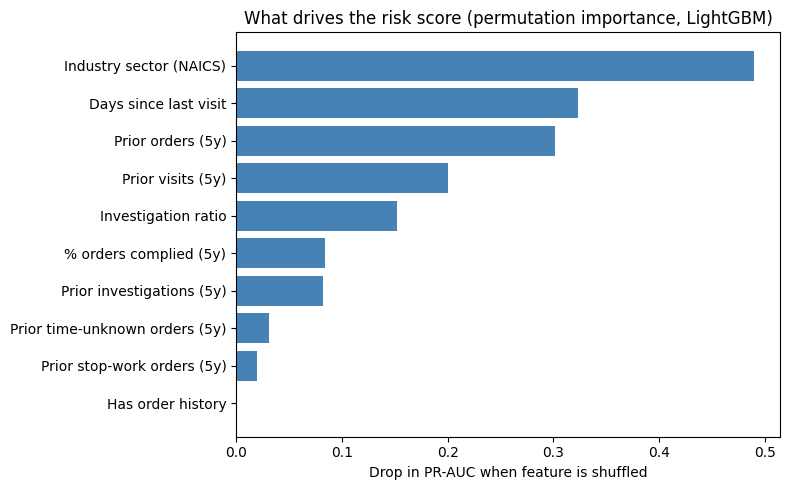

Saved /Users/user/Desktop/Technical Project/MLITSD-DS-Project/data/processed/feature_importance.png


naics_sector                   0.490
log1p_days_since_last_visit    0.324
log1p_n_orders_5y              0.301
log1p_n_visits_5y              0.200
investigation_ratio            0.152
pct_complied_5y                0.084
log1p_n_investigations_5y      0.082
log1p_n_time_unknown_5y        0.031
log1p_n_stop_work_5y           0.020
has_order_history              0.001
dtype: float64

In [4]:
perm = permutation_importance(
    gbm, Xgb, y, scoring="average_precision", n_repeats=5, random_state=42,
)
imp = (pd.Series(perm.importances_mean, index=FEATURES)
       .sort_values(ascending=True))

labels = {
    "log1p_n_orders_5y": "Prior orders (5y)",
    "log1p_n_visits_5y": "Prior visits (5y)",
    "log1p_n_investigations_5y": "Prior investigations (5y)",
    "log1p_n_stop_work_5y": "Prior stop-work orders (5y)",
    "log1p_n_time_unknown_5y": "Prior time-unknown orders (5y)",
    "log1p_days_since_last_visit": "Days since last visit",
    "investigation_ratio": "Investigation ratio",
    "pct_complied_5y": "% orders complied (5y)",
    "has_order_history": "Has order history",
    "naics_sector": "Industry sector (NAICS)",
}
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([labels.get(i, i) for i in imp.index], imp.values, color="steelblue")
ax.set_xlabel("Drop in PR-AUC when feature is shuffled")
ax.set_title("What drives the risk score (permutation importance, LightGBM)")
fig.tight_layout()
fig.savefig(OUT / "feature_importance.png", dpi=150)
plt.show()
print("Saved", OUT / "feature_importance.png")
imp.sort_values(ascending=False).round(3)

## 5. Conclusion

- **Robustness confirmed:** gradient boosting matched (did not beat) the logistic baseline out-of-fold — the signal is not a linear-model artifact.
- **Decision (D014):** keep **logistic regression as the primary model** for explainability; cite boosting as a robustness check.
- **Top drivers** (consistent with Phase 3 coefficients): industry sector, enforcement history (orders / investigations), recency of contact, and compliance behaviour.
- **Artifact for slides:** `data/processed/feature_importance.png`.

**Interview line:** "I validated the logistic model with gradient boosting. Out-of-fold, performance was essentially identical — so the simpler, fully explainable model is the right choice for an enforcement setting, with no accuracy penalty."